In [91]:
import pandas as pd
import seaborn as sns
import numpy as np
import os
import matplotlib.pyplot as plt
import openml
import yaml
import tqdm
from pymoo.indicators.hv import HV
import warnings
from multiprocessing import Pool
from joblib import Parallel, delayed
from utility import compute_min_max, get_pareto_front, compute_ranks, compute_extremes, get_all_dataframes, get_group_task_ids
from colors import COLORS
from itertools import product
import gc
from concurrent.futures import ProcessPoolExecutor

COLOR_LIST = list(COLORS.values())

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [94]:
def plot_bars(labels_cols, matrix, groups_dict):
    # ---- build grouped bar order ----
    labels_bars = []
    group_centers = {}
    y_positions = []

    y = 0
    for group, bars in groups_dict.items():
        start = y
        for bar in bars:
            labels_bars.append(bar)
            y_positions.append(y)
            y += 1
        end = y - 1
        group_centers[group] = (start + end) / 2
        y += 0.5  # gap between groups

    n_labels = len(labels_bars)
    n_cols = len(labels_cols)
    n_datasets = matrix.shape[2]

    mean = np.mean(matrix, axis=2)
    std = np.std(matrix, axis=2)

    fig, ax = plt.subplots(figsize=(10, 6), ncols=n_cols, sharey=True)

    y_positions = np.array(y_positions)

    for i, label_col in enumerate(labels_cols):
        colors = sns.color_palette(
            "viridis", as_cmap=True
        )(
            (mean[:, i] - mean[:, i].min())
            / (mean[:, i].max() - mean[:, i].min() + 1e-9)
        )

        ax[i].barh(
            y_positions,
            mean[:, i],
            xerr=std[:, i],
            color=colors
        )

        ax[i].set_yticks(y_positions)
        ax[i].set_yticklabels(labels_bars)
        #ax[i].set_title(label_col)
        ax[i].set_xlabel(label_col)

        # styling
        ax[i].spines['top'].set_visible(False)
        ax[i].spines['right'].set_visible(False)
        ax[i].spines['left'].set_visible(False)
        ax[i].yaxis.set_tick_params(length=0)

    # ---- group labels on the left ----
    left_ax = ax[0]
    x_min = left_ax.get_xlim()[0]

    for group, center in group_centers.items():
        left_ax.text(
            -0.28,                 # ⬅ left of tick labels
            center,
            group,
            transform=left_ax.get_yaxis_transform(),
            rotation=90,
            va='center',
            ha='center',
            fontsize=11,
            fontweight='bold'
        )

    # invert shared y-axis ONCE
    ax[0].invert_yaxis()

    plt.tight_layout()
    plt.show()

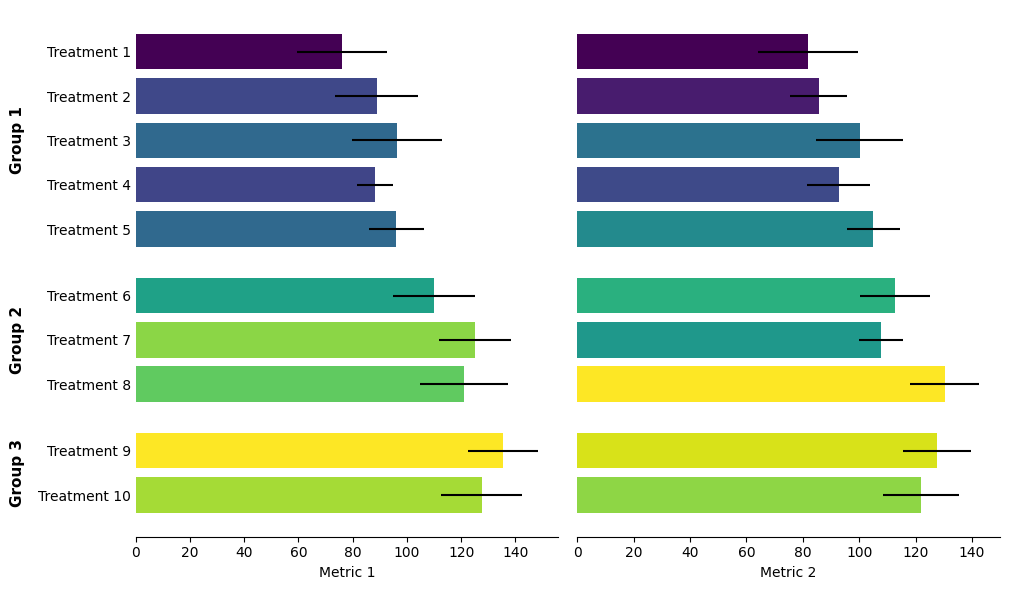

In [95]:
n_treatments = 10
n_cols = 2
n_datasets = 5

rand_matrix =  60 + np.arange(n_treatments).reshape(n_treatments, 1, 1)*5 + 50*np.random.rand(n_treatments, n_cols, n_datasets)
labels_bars = [f'Treatment {i+1}' for i in range(n_treatments)]
labels_cols = [f'Metric {i+1}' for i in range(n_cols)]

groups = {"Group 1" : labels_bars[:5], "Group 2" : labels_bars[5:8], "Group 3" : labels_bars[8:]}
plot_bars(labels_cols, rand_matrix, groups)